In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, confusion_matrix
from mpl_toolkits.mplot3d import Axes3D

In [2]:
iris = load_iris()
X = iris.data
y_true = iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y_true, iris.target_names)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


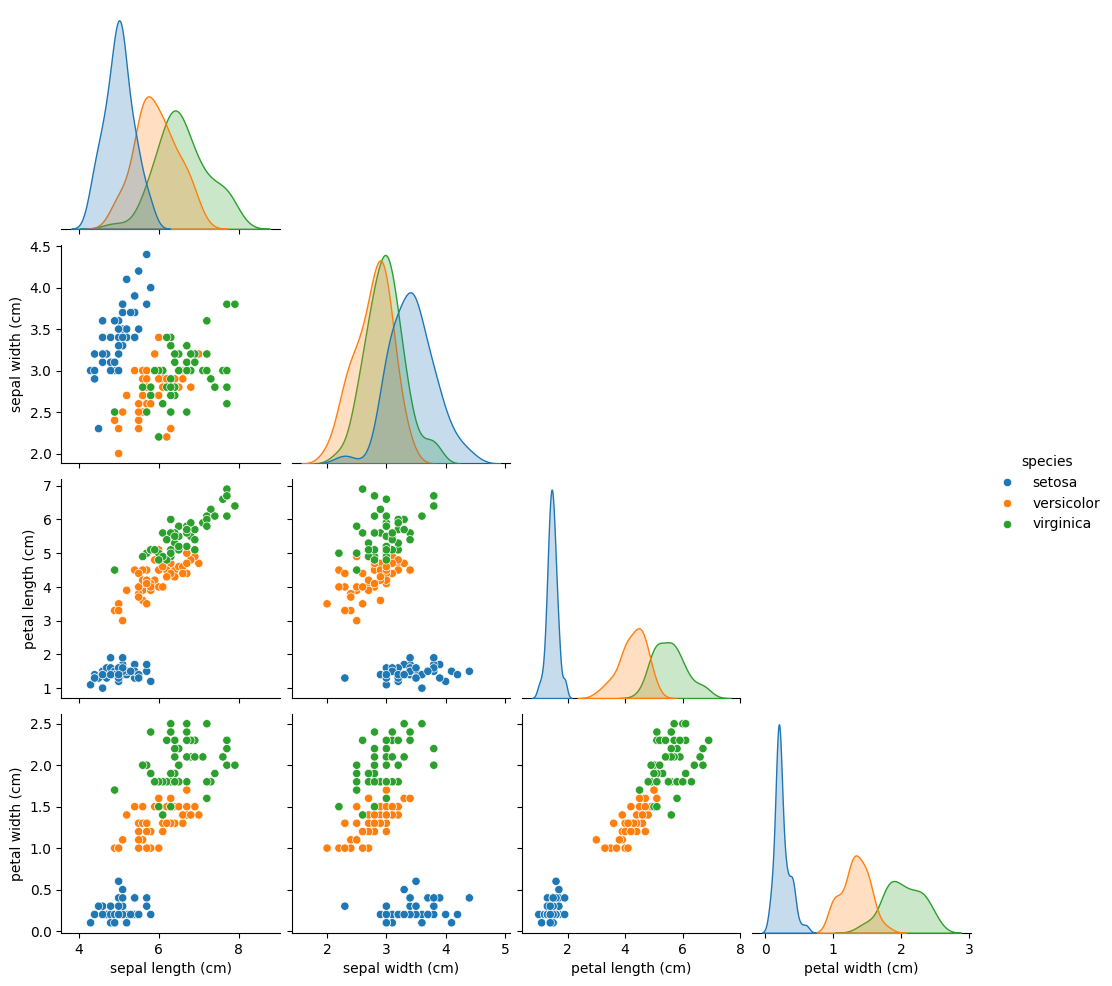

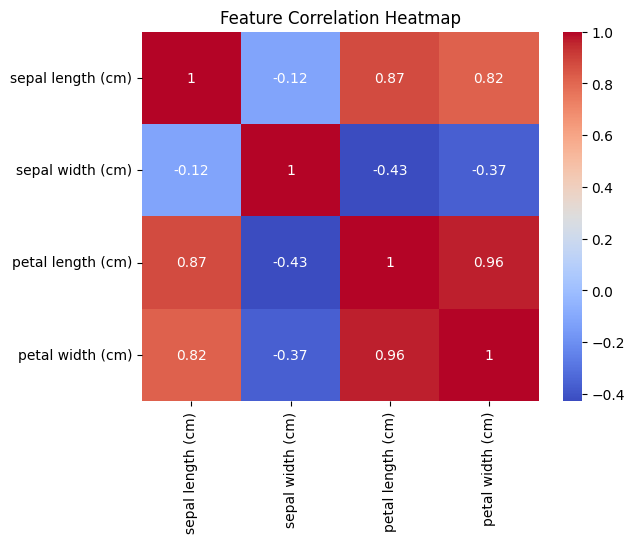

In [3]:
sns.pairplot(df, hue='species', diag_kind='kde', corner=True)
plt.show()

sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

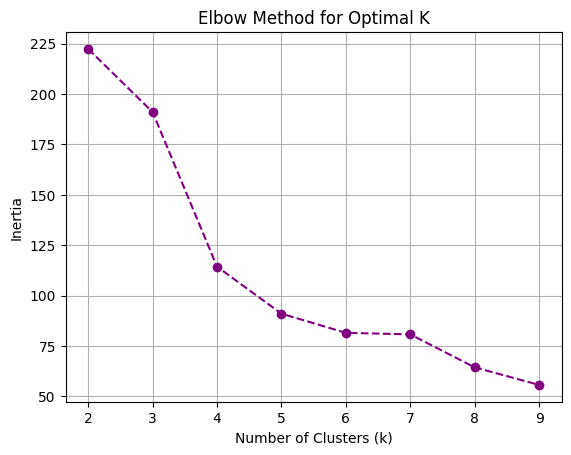

In [5]:
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'o--', color='purple')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

print("Cluster Centers (scaled):\n", kmeans.cluster_centers_)
print("Silhouette Score:", silhouette_score(X_scaled, y_kmeans))

Cluster Centers (scaled):
 [[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]
Silhouette Score: 0.4798814508199817


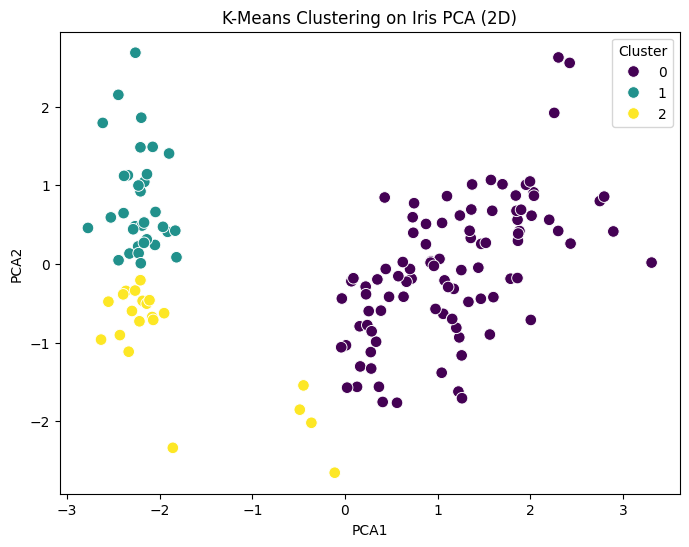

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': y_kmeans
})

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', s=70)
plt.title("K-Means Clustering on Iris PCA (2D)")
plt.show()


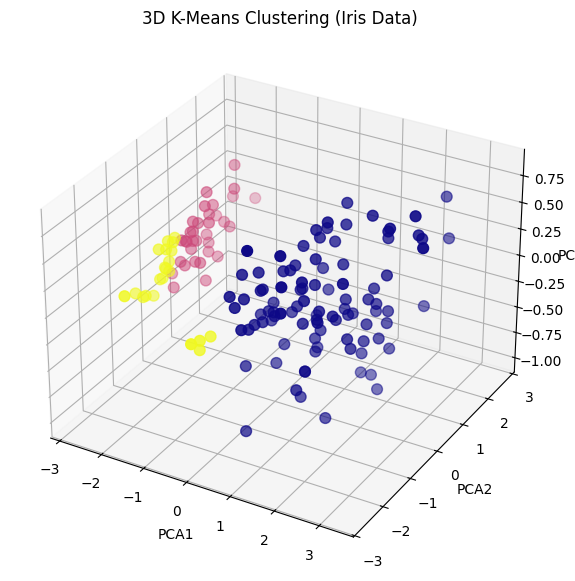

In [8]:
pca_3d = PCA(n_components=3)
X_pca3 = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca3[:, 0],
    X_pca3[:, 1],
    X_pca3[:, 2],
    c=y_kmeans,
    cmap='plasma',
    s=60
)

ax.set_title("3D K-Means Clustering (Iris Data)")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.show()

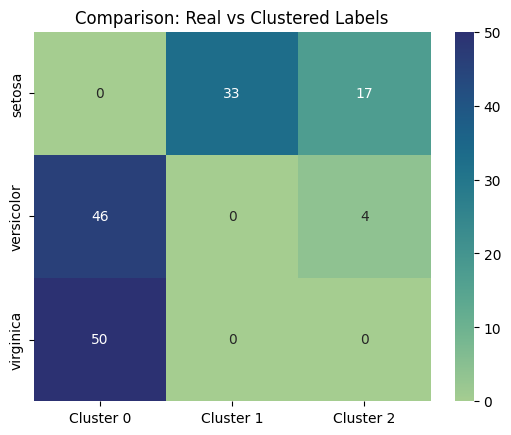

In [9]:
labels_compare = pd.DataFrame({'True': y_true, 'Clustered': y_kmeans})
cm = confusion_matrix(labels_compare['True'], labels_compare['Clustered'])
cm_df = pd.DataFrame(cm, index=iris.target_names, columns=['Cluster 0','Cluster 1','Cluster 2'])

sns.heatmap(cm_df, annot=True, fmt='d', cmap='crest')
plt.title("Comparison: Real vs Clustered Labels")
plt.show()


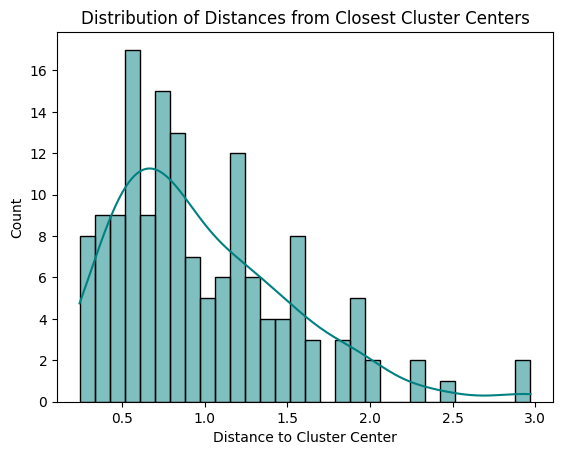

In [10]:
distances = kmeans.transform(X_scaled).min(axis=1)
sns.histplot(distances, bins=30, kde=True, color='teal')
plt.title("Distribution of Distances from Closest Cluster Centers")
plt.xlabel("Distance to Cluster Center")
plt.show()

In [11]:
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=iris.feature_names)
print("\nCluster Centers in Original Feature Space:\n")
print(centers_df)


Cluster Centers in Original Feature Space:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           6.314583          2.895833           4.973958          1.703125
1           5.169697          3.630303           1.493939          0.272727
2           4.747619          2.895238           1.757143          0.352381
